# Notebook 04 — Targeted assembly and variant analysis
## *S. elongatus* MN-Col-091924-B vs. PCC 7942

This notebook performs a targeted recovery and comparison of an environmental *Synechococcus elongatus*-like strain sequenced from Columbia Lake, MN (sample MN-Col-091924-B, ~168× metagenome coverage). The workflow:

1. Download the PCC 7942 reference genome (chromosome + plasmid)
2. Map the sample's filtered ONT reads to the reference and extract the mapped subset
3. Assemble the extracted reads with Flye in single-genome mode
4. Polish the assembly with two rounds of Racon
5. Call variants between the polished assembly and PCC 7942 using minimap2 `--cs` tag parsing
6. Visualise synteny (circular plot) and variant distribution (linear + circular density plots)
7. Investigate specific regions of interest (rRNA hotspot, intergenic deletions, conserved hypotheticals)

**Run cells in order.** All expensive steps are cached to disk — re-running a cell is safe.

In [2]:
# ── 0. Setup ─────────────────────────────────────────────────────────────────
from pathlib import Path
import subprocess, json, sys, time
from Bio import SeqIO, Entrez
import pandas as pd

# Bootstrap: find project root to load shared utilities
_p = Path.cwd().resolve()
for _parent in [_p] + list(_p.parents):
    if (_parent / 'Snakefile').exists():
        sys.path.insert(0, str(_parent / 'notebooks'))
        break
from utils import find_project_root, load_config

PROJECT  = find_project_root()
cfg      = load_config()
Entrez.email = cfg.get('entrez_email', 'jaepeiso@uchicago.edu')

SAMPLE   = 'MN-Col-091924-B'
READS    = PROJECT / 'results' / '02_filter' / f'{SAMPLE}.flt.fq.gz'
REF_DIR  = PROJECT / 'results' / 'ref'
OUT_DIR  = PROJECT / 'results' / '15_env7942'
FIG_DIR  = PROJECT / 'results' / 'figures'

REF_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

REF_FA   = REF_DIR / 'PCC7942_reference.fasta'
ASSEMBLY = OUT_DIR / 'flye_assembly' / 'assembly.fasta'
POLISH1  = OUT_DIR / 'racon1.fasta'
POLISH2  = OUT_DIR / 'racon2.fasta'

print('Project root:', PROJECT)
print('Sample reads:', READS)
print('Reference:   ', REF_FA)
print('Output dir:  ', OUT_DIR)

Project root: /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome
Sample reads: /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/02_filter/MN-Col-091924-B.flt.fq.gz
Reference:    /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/ref/PCC7942_reference.fasta
Output dir:   /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/15_env7942


### Environment check
Verifies that all required external tools are available on `PATH` before any subprocess calls.

In [3]:
import shutil

# ── Tool availability check — run before any other cells ─────────────────────
_required = {
    'minimap2':  'minimap2  (conda: minimap2)',
    'samtools':  'samtools  (conda: samtools)',
    'flye':      'Flye      (conda: flye)',
    'racon':     'Racon     (conda: racon)',
    'bcftools':  'bcftools  (conda: bcftools)',
}
_missing = {tool: pkg for tool, pkg in _required.items() if not shutil.which(tool)}
if _missing:
    raise EnvironmentError(
        "Missing tools — activate the correct conda environment before running:\n" +
        "\n".join(f"  {tool:10s}  {pkg}" for tool, pkg in _missing.items())
    )
print("Tool check passed:", list(_required))
if not READS.exists():
    raise FileNotFoundError(f"Filtered reads not found: {READS}\nRun the Snakemake filter step first.")

Tool check passed: ['minimap2', 'samtools', 'flye', 'racon', 'bcftools']


## Step 1: Download PCC 7942 reference genome

In [4]:
# ── 1. Download PCC 7942 reference (CP000100.1 + CP000101.1) ─────────────────
# Chromosome CP000100.1 (~2.7 Mb) + plasmid pANL CP000101.1 (~46 kb).
# Cached: skips download if file already exists.

ACCESSIONS = ['CP000100.1', 'CP000101.1']

if REF_FA.exists():
    seqs = list(SeqIO.parse(REF_FA, 'fasta'))
    total_bp = sum(len(r.seq) for r in seqs)
    print(f'Reference already downloaded: {REF_FA.name}')
    print(f'  {len(seqs)} sequences, {total_bp:,} bp total')
else:
    records = []
    for acc in ACCESSIONS:
        print(f'Fetching {acc} from NCBI...')
        handle = Entrez.efetch(db='nucleotide', id=acc, rettype='fasta', retmode='text')
        rec = SeqIO.read(handle, 'fasta')
        handle.close()
        records.append(rec)
        print(f'  {acc}: {len(rec.seq):,} bp')
        time.sleep(1)   # be polite to NCBI rate limits
    SeqIO.write(records, REF_FA, 'fasta')
    total_bp = sum(len(r.seq) for r in records)
    print(f'\nSaved {len(records)} sequences → {REF_FA}')
    print(f'Total reference size: {total_bp:,} bp')

Fetching CP000100.1 from NCBI...
  CP000100.1: 2,695,903 bp
Fetching CP000101.1 from NCBI...
  CP000101.1: 46,366 bp

Saved 2 sequences → /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/ref/PCC7942_reference.fasta
Total reference size: 2,742,269 bp


## Step 2: Map reads to PCC 7942 reference, extract mapped subset

In [5]:
# ── 2. Map MN-Col filtered reads → PCC 7942 reference ────────────────────────
# minimap2 map-ont preset (long reads, moderate identity).
# Extract only mapped reads (samtools -F 4) for targeted reassembly.

MAPPED_BAM    = OUT_DIR / f'{SAMPLE}_vs_PCC7942.bam'
MAPPED_READS  = OUT_DIR / f'{SAMPLE}_mapped.fastq.gz'

if MAPPED_READS.exists():
    # Count mapped reads
    n = int(subprocess.check_output(
        ['samtools', 'view', '-c', str(MAPPED_BAM)], text=True).strip())
    print(f'Mapped reads already extracted: {MAPPED_READS.name} ({n:,} alignments)')
else:
    print('Mapping reads with minimap2 (map-ont)...')
    # Map → sort → index
    with open(MAPPED_BAM, 'wb') as bam_fh:
        mm2 = subprocess.Popen(
            ['minimap2', '-ax', 'map-ont', '-t', '8',
             str(REF_FA), str(READS)],
            stdout=subprocess.PIPE, stderr=subprocess.DEVNULL)
        sort = subprocess.Popen(
            ['samtools', 'sort', '-@', '4', '-'],
            stdin=mm2.stdout, stdout=bam_fh)
        mm2.stdout.close()
        sort.communicate()
    subprocess.run(['samtools', 'index', str(MAPPED_BAM)], check=True)

    n_total = int(subprocess.check_output(
        ['samtools', 'view', '-c', str(MAPPED_BAM)], text=True).strip())
    n_mapped = int(subprocess.check_output(
        ['samtools', 'view', '-c', '-F', '4', str(MAPPED_BAM)], text=True).strip())
    print(f'  Total alignments: {n_total:,}')
    print(f'  Mapped:           {n_mapped:,}  ({n_mapped/max(n_total,1)*100:.1f}%)')

    # Extract mapped reads as FASTQ
    print('Extracting mapped reads...')
    with open(MAPPED_READS, 'wb') as fq_fh:
        view = subprocess.Popen(
            ['samtools', 'view', '-b', '-F', '4', str(MAPPED_BAM)],
            stdout=subprocess.PIPE)
        fq   = subprocess.Popen(
            ['samtools', 'fastq', '-'],
            stdin=view.stdout, stdout=subprocess.PIPE)
        gzip = subprocess.Popen(
            ['gzip'], stdin=fq.stdout, stdout=fq_fh)
        view.stdout.close(); fq.stdout.close(); gzip.communicate()
    print(f'Saved mapped reads → {MAPPED_READS.name}')

Mapping reads with minimap2 (map-ont)...


[bam_sort_core] merging from 0 files and 4 in-memory blocks...


  Total alignments: 288,384
  Mapped:           146,468  (50.8%)
Extracting mapped reads...


samtools fastq: Coordinate sorted file.  Read pairs may be out of order


Saved mapped reads → MN-Col-091924-B_mapped.fastq.gz


[M::bam2fq_mainloop] discarded 0 singletons
[M::bam2fq_mainloop] processed 141381 reads


## Step 3: Flye assembly (single-genome, --nano-hq)

In [6]:
# ── 3. Flye targeted assembly of the extracted reads ─────────────────────────
# Using --nano-hq (single-genome mode, NOT --meta) because we extracted reads
# that map to a single reference, so we expect near-uniform coverage.

FLYE_DIR = OUT_DIR / 'flye_assembly'

if ASSEMBLY.exists():
    seqs = list(SeqIO.parse(ASSEMBLY, 'fasta'))
    total_bp = sum(len(r.seq) for r in seqs)
    print(f'Flye assembly already exists: {len(seqs)} contigs, {total_bp:,} bp')
else:
    print('Running Flye (--nano-hq)...')
    cmd = [
        'flye',
        '--nano-hq',   str(MAPPED_READS),
        '--out-dir',   str(FLYE_DIR),
        '--threads',   '8',
    ]
    print('CMD:', ' '.join(cmd))
    subprocess.run(cmd, check=True)
    seqs = list(SeqIO.parse(ASSEMBLY, 'fasta'))
    total_bp = sum(len(r.seq) for r in seqs)
    print(f'\nFlye done: {len(seqs)} contigs, {total_bp:,} bp → {ASSEMBLY}')

Running Flye (--nano-hq)...
CMD: flye --nano-hq /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/15_env7942/MN-Col-091924-B_mapped.fastq.gz --out-dir /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/15_env7942/flye_assembly --threads 8


[2026-04-06 15:16:15] INFO: Starting Flye 2.9.6-b1802
[2026-04-06 15:16:15] INFO: >>>STAGE: configure
[2026-04-06 15:16:15] INFO: Configuring run
[2026-04-06 15:16:18] INFO: Total read length: 481286518
[2026-04-06 15:16:18] INFO: Reads N50/N90: 4021 / 1883
[2026-04-06 15:16:18] INFO: Minimum overlap set to 2000
[2026-04-06 15:16:18] INFO: >>>STAGE: assembly
[2026-04-06 15:16:18] INFO: Assembling disjointigs
[2026-04-06 15:16:18] INFO: Reading sequences
[2026-04-06 15:16:21] INFO: Building minimizer index
[2026-04-06 15:16:21] INFO: Pre-calculating index storage
0% 10% 20% 30% 40% 50% 60% 70% 80% 90% 100% 
[2026-04-06 15:16:24] INFO: Filling index
0% 10% 20% 30% 40% 50% 60% 70% 80% 90% 100% 
[2026-04-06 15:16:30] INFO: Extending reads
[2026-04-06 15:16:48] INFO: Overlap-based coverage: 131
[2026-04-06 15:16:48] INFO: Median overlap divergence: 0.00897308
0% 90% 100% 
[2026-04-06 15:17:18] INFO: Assembled 5 disjointigs
[2026-04-06 15:17:18] INFO: Generating sequence
0% 10% 20% 30% 40% 5


Flye done: 3 contigs, 2,762,067 bp → /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/15_env7942/flye_assembly/assembly.fasta


[2026-04-06 15:20:20] INFO: >>>STAGE: finalize
[2026-04-06 15:20:20] INFO: Assembly statistics:

	Total length:	2762067
	Fragments:	3
	Fragments N50:	2695903
	Largest frg:	2695903
	Scaffolds:	0
	Mean coverage:	176

[2026-04-06 15:20:20] INFO: Final assembly: /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/15_env7942/flye_assembly/assembly.fasta


## Step 4: Two rounds of Racon polishing

In [7]:
# ── 4. Racon polish — two rounds ─────────────────────────────────────────────

def racon_round(reads, assembly, out_fasta, label='round'):
    """Run one round of Racon polishing. Skips if out_fasta already exists."""
    if out_fasta.exists():
        print(f'Racon {label}: already done → {out_fasta.name}')
        return
    paf = out_fasta.with_suffix('.paf')
    print(f'Racon {label}: mapping reads...')
    with open(paf, 'w') as paf_fh:
        subprocess.run(
            ['minimap2', '-x', 'map-ont', '-t', '8',
             str(assembly), str(reads)],
            stdout=paf_fh, stderr=subprocess.DEVNULL, check=True)
    print(f'Racon {label}: polishing...')
    with open(out_fasta, 'w') as out_fh:
        subprocess.run(
            ['racon', '-t', '8', str(reads), str(paf), str(assembly)],
            stdout=out_fh, check=True)
    seqs = list(SeqIO.parse(out_fasta, 'fasta'))
    print(f'Racon {label}: done — {len(seqs)} contigs → {out_fasta.name}')

racon_round(MAPPED_READS, ASSEMBLY,  POLISH1, 'round 1')
racon_round(MAPPED_READS, POLISH1,   POLISH2, 'round 2')

# Report final assembly stats
seqs = list(SeqIO.parse(POLISH2, 'fasta'))
lengths = sorted([len(r.seq) for r in seqs], reverse=True)
n50 = next(l for i, l in enumerate(lengths) if sum(lengths[:i+1]) >= sum(lengths)/2)
print(f'\nFinal polished assembly: {len(seqs)} contigs, '
      f'{sum(lengths):,} bp total, N50={n50:,} bp')

Racon round 1: mapping reads...
Racon round 1: polishing...


[racon::Polisher::initialize] loaded target sequences 0.011953 s
[racon::Polisher::initialize] loaded sequences 3.840877 s
[racon::Polisher::initialize] loaded overlaps 0.076413 s
[racon::Polisher::initialize] aligning overlaps [====================] 5.561571 s
[racon::Polisher::initialize] transformed data into windows 0.300618 s
[racon::Polisher::polish] generating consensus [====================] 92.200202 s
[racon::Polisher::] total = 102.079132 s


Racon round 1: done — 3 contigs → racon1.fasta
Racon round 2: mapping reads...
Racon round 2: polishing...


[racon::Polisher::initialize] loaded target sequences 0.008750 s
[racon::Polisher::initialize] loaded sequences 3.901217 s
[racon::Polisher::initialize] loaded overlaps 0.078558 s
[racon::Polisher::initialize] aligning overlaps [====================] 6.199819 s
[racon::Polisher::initialize] transformed data into windows 0.309531 s


Racon round 2: done — 3 contigs → racon2.fasta

Final polished assembly: 3 contigs, 2,760,742 bp total, N50=2,695,425 bp


[racon::Polisher::polish] generating consensus [====================] 92.271136 s
[racon::Polisher::] total = 102.860314 s


## Step 5: Call variants (minimap2 --cs + cs-tag parsing)

In [114]:
# ── 5. Variant calling via minimap2 --cs tag parsing ─────────────────────────
# bcftools mpileup is designed for read pileups (many independent reads), not
# assembly-to-reference comparison (coverage = 1). Instead we use minimap2's
# --cs tag, which encodes every mismatch and indel directly in the alignment.
# This is the approach recommended in the minimap2 manual for assembly comparison.
#
# cs tag operators:
#   :N   — N identical bases
#   *xy  — substitution: ref base x → query base y  (SNP)
#   +seq — insertion in query relative to reference
#   -seq — deletion in query relative to reference (absent in env assembly)

import re

PAF_CS = OUT_DIR / 'env7942_vs_PCC7942_cs.paf'

# ── 5a. Generate PAF with --cs flag ──────────────────────────────────────────
if not PAF_CS.exists():
    print('Aligning assembly to reference (asm5, --cs)...')
    with open(PAF_CS, 'w') as fh:
        subprocess.run(
            ['minimap2', '-cx', 'asm5', '--cs', '-t', '4',
             str(REF_FA), str(POLISH2)],
            stdout=fh, stderr=subprocess.DEVNULL, check=True)
    print(f'PAF saved → {PAF_CS.name}')
else:
    print(f'PAF already exists: {PAF_CS.name}')

# ── 5b. Parse cs tags ─────────────────────────────────────────────────────────
snps, insertions, deletions = [], [], []

with open(PAF_CS) as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) < 12:
            continue
        mapq = int(parts[11])
        if mapq < 20:
            continue
        t_name  = parts[5]
        t_start = int(parts[7])
        cs_tag  = next((x[5:] for x in parts[12:] if x.startswith('cs:Z:')), None)
        if cs_tag is None:
            continue

        ref_pos = t_start
        for m in re.finditer(r':[0-9]+|\*[a-z][a-z]|\+[a-z]+|-[a-z]+', cs_tag):
            op = m.group(0)
            if op[0] == ':':
                ref_pos += int(op[1:])
            elif op[0] == '*':
                snps.append({'chrom': t_name, 'pos': ref_pos + 1,
                             'ref': op[1].upper(), 'alt': op[2].upper()})
                ref_pos += 1
            elif op[0] == '+':
                insertions.append({'chrom': t_name, 'pos': ref_pos + 1,
                                   'seq': op[1:].upper(), 'len': len(op) - 1})
            elif op[0] == '-':
                deletions.append({'chrom': t_name, 'pos': ref_pos + 1,
                                  'seq': op[1:].upper(), 'len': len(op) - 1})
                ref_pos += len(op) - 1

# ── 5c. Summary table ─────────────────────────────────────────────────────────
ins_bp = sum(d['len'] for d in insertions)
del_bp = sum(d['len'] for d in deletions)

summary = pd.DataFrame([
    {'Type': 'SNPs',                      'Count': len(snps),       'Total bp': len(snps)},
    {'Type': 'Insertions (env vs ref)',   'Count': len(insertions), 'Total bp': ins_bp},
    {'Type': 'Deletions (env vs ref)',    'Count': len(deletions),  'Total bp': del_bp},
])
print('\nVariant summary (environmental assembly vs PCC 7942):')
print(summary.to_string(index=False))
print(f'\nNet size difference: {ins_bp - del_bp:+,} bp  '
      f'(assembly is {ins_bp - del_bp:+,} bp relative to reference)')

# Store dataframes for downstream use
df_snps = pd.DataFrame(snps) if snps else pd.DataFrame(columns=['chrom','pos','ref','alt'])
df_ins  = pd.DataFrame(insertions) if insertions else pd.DataFrame(columns=['chrom','pos','seq','len'])
df_del  = pd.DataFrame(deletions)  if deletions  else pd.DataFrame(columns=['chrom','pos','seq','len'])

PAF already exists: env7942_vs_PCC7942_cs.paf

Variant summary (environmental assembly vs PCC 7942):
                   Type  Count  Total bp
                   SNPs     14        14
Insertions (env vs ref)      1         7
 Deletions (env vs ref)     16        61

Net size difference: -54 bp  (assembly is -54 bp relative to reference)


## Step 6: Circular synteny plot vs PCC 7942 reference

1 chains ≥50 kb
Assembly orientation: reverse dominant
Assembly rotated by -13.1°


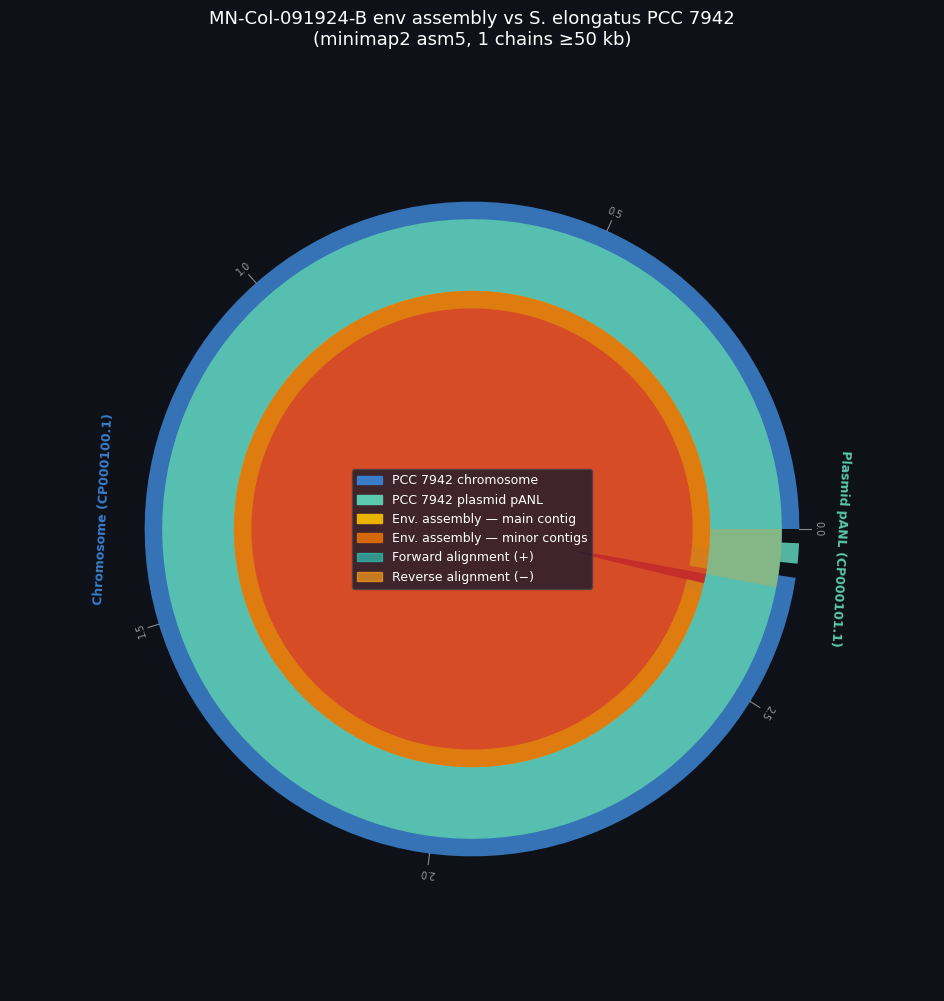

Figure saved → MN-Col-091924-B_vs_PCC7942_circular.pdf


In [115]:
# ── 6. Circular synteny plot ─────────────────────────────────────────────────
# Layout:
#   Outer ring (R=1.00): PCC 7942 reference (chromosome + plasmid)
#   Inner ring (R=0.72): Environmental assembly (contigs colored by size)
#   Ribbons:             Alignment chains ≥50 kb (colored by strand)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from Bio import SeqIO

MIN_LINK = 50_000   # minimum alignment chain length to draw
REF_R    = 1.00     # reference ring center radius
ASM_R    = 0.72     # assembly ring center radius
TRACK_W  = 0.055    # ring thickness
GAP      = np.radians(2.5)  # gap between sequences on each ring

# ── Load sequence lengths ──────────────────────────────────────────────────────
ref_seqs = list(SeqIO.parse(REF_FA, 'fasta'))
asm_seqs = list(SeqIO.parse(POLISH2, 'fasta'))
ref_total = sum(len(r.seq) for r in ref_seqs)
asm_total = sum(len(r.seq) for r in asm_seqs)

ref_off = {}
_o = 0
for r in ref_seqs:
    ref_off[r.id] = _o; _o += len(r.seq)

asm_off = {}
_o = 0
for r in asm_seqs:
    asm_off[r.id] = _o; _o += len(r.seq)

# ── Parse PAF alignments ───────────────────────────────────────────────────────
alns = []
with open(PAF_CS) as f:
    for line in f:
        p = line.strip().split('\t')
        if len(p) < 12 or int(p[11]) < 20: continue
        if int(p[8]) - int(p[7]) < MIN_LINK: continue
        alns.append({'qn': p[0], 'qs': int(p[2]), 'qe': int(p[3]),
                     'strand': p[4], 'tn': p[5],
                     'ts': int(p[7]), 'te': int(p[8])})
print(f'{len(alns)} chains ≥{MIN_LINK//1000} kb')

# ── Detect dominant orientation and compute rotation ──────────────────────────
rev_bp = sum(a['te']-a['ts'] for a in alns if a['strand'] == '-')
fwd_bp = sum(a['te']-a['ts'] for a in alns if a['strand'] == '+')
flip   = rev_bp > fwd_bp
print(f'Assembly orientation: {"reverse" if flip else "forward"} dominant')

# Rotation: align largest alignment's reference start to assembly start
lg = max(alns, key=lambda a: a['te']-a['ts'])
ref_anchor = ((ref_off.get(lg['tn'], 0) + lg['ts']) / ref_total) * 2*np.pi
raw_q = asm_total - (asm_off.get(lg['qn'], 0) + lg['qe']) if flip \
        else asm_off.get(lg['qn'], 0) + lg['qs']
asm_rot = ref_anchor - (raw_q / asm_total) * 2*np.pi
print(f'Assembly rotated by {np.degrees(asm_rot):.1f}°')

# ── Coordinate helpers ─────────────────────────────────────────────────────────
def r_angle(tn, pos):
    return ((ref_off[tn] + pos) / ref_total) * 2*np.pi

def a_angle(qn, pos):
    abs_p = asm_total - (asm_off.get(qn,0) + pos) if flip \
            else asm_off.get(qn, 0) + pos
    return (abs_p / asm_total) * 2*np.pi + asm_rot

def arc_pts(a0, a1, r, n=120):
    if a1 < a0: a1 += 2*np.pi
    a = np.linspace(a0, a1, n)
    return np.column_stack([r*np.cos(a), r*np.sin(a)])

def bezier(p0, p1, p2, p3, n=40):
    t = np.linspace(0, 1, n)[:,None]
    return ((1-t)**3*np.array(p0) + 3*(1-t)**2*t*np.array(p1)
            + 3*(1-t)*t**2*np.array(p2) + t**3*np.array(p3))

def pt(angle, r): return np.array([r*np.cos(angle), r*np.sin(angle)])

def draw_ribbon(ax, ra1, ra2, aa1, aa2, rr, ar, color, alpha=0.28):
    cp = 0.20   # control-point fraction toward center
    b1 = bezier(pt(ra1,rr), pt(ra1,rr)*cp, pt(aa1,ar)*cp, pt(aa1,ar))
    b2 = bezier(pt(aa2,ar), pt(aa2,ar)*cp, pt(ra2,rr)*cp, pt(ra2,rr))
    pts = np.vstack([b1, arc_pts(aa1, aa2, ar), b2, arc_pts(ra2, ra1, rr)])
    ax.fill(pts[:,0], pts[:,1], color=color, alpha=alpha, linewidth=0)

# ── Draw ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 12))
ax.set_aspect('equal'); ax.axis('off')
ax.set_xlim(-1.45, 1.45); ax.set_ylim(-1.45, 1.45)
ax.set_facecolor('#0e1117'); fig.patch.set_facecolor('#0e1117')

REF_COLORS = {'CP000100.1': '#3A7DC9', 'CP000101.1': '#5BC8AF'}
REF_LABELS = {'CP000100.1': 'Chromosome (CP000100.1)',
              'CP000101.1': 'Plasmid pANL (CP000101.1)'}
ASM_COLORS = ['#E8B400', '#D4680A', '#C4262E']

# Reference ring
for r in ref_seqs:
    acc = r.id.split()[0]
    a0  = r_angle(r.id, 0)
    a1  = r_angle(r.id, len(r.seq)) - GAP
    po  = arc_pts(a0, a1, REF_R + TRACK_W/2)
    pi  = arc_pts(a1, a0, REF_R - TRACK_W/2)
    ax.fill(*np.vstack([po,pi]).T, color=REF_COLORS.get(acc,'#888'), alpha=0.9, lw=0)

# Assembly ring
for i, r in enumerate(asm_seqs):
    a0 = a_angle(r.id, 0)
    a1 = a_angle(r.id, len(r.seq))
    if a1 < a0: a0, a1 = a1, a0   # ensure CCW
    a1 -= GAP
    po = arc_pts(a0, a1, ASM_R + TRACK_W/2)
    pi = arc_pts(a1, a0, ASM_R - TRACK_W/2)
    ax.fill(*np.vstack([po,pi]).T, color=ASM_COLORS[i % 3], alpha=0.9, lw=0)

# Ribbons
LINK_C = {'+': '#2EC4B6', '-': '#FF9F1C'}
for aln in alns:
    ra1 = r_angle(aln['tn'], aln['ts'])
    ra2 = r_angle(aln['tn'], aln['te'])
    if aln['strand'] == '-':   # reverse: q_end maps to ref t_start
        aa1 = a_angle(aln['qn'], aln['qe'])
        aa2 = a_angle(aln['qn'], aln['qs'])
    else:
        aa1 = a_angle(aln['qn'], aln['qs'])
        aa2 = a_angle(aln['qn'], aln['qe'])
    if aa2 < aa1: aa1, aa2 = aa2, aa1  # ensure CCW
    draw_ribbon(ax, ra1, ra2, aa1, aa2,
                REF_R - TRACK_W/2, ASM_R + TRACK_W/2,
                LINK_C[aln['strand']])

# Tick marks every 500 kb on reference
for pos in range(0, ref_total, 500_000):
    tn = next(r.id for r in ref_seqs
              if ref_off[r.id] <= pos < ref_off[r.id] + len(r.seq))
    ang = r_angle(tn, pos - ref_off[tn])
    r0, r1 = REF_R + TRACK_W/2, REF_R + TRACK_W/2 + 0.035
    ax.plot([r0*np.cos(ang), r1*np.cos(ang)],
            [r0*np.sin(ang), r1*np.sin(ang)], color='white', lw=0.8, alpha=0.5)
    ax.text((r1+0.025)*np.cos(ang), (r1+0.025)*np.sin(ang),
            f'{pos/1e6:.1f}', ha='center', va='center',
            color='#999', fontsize=7,
            rotation=np.degrees(ang) % 360 - 90)

# Sequence labels
for r in ref_seqs:
    acc = r.id.split()[0]
    mid = r_angle(r.id, len(r.seq)/2)
    lx  = (REF_R + TRACK_W/2 + 0.13) * np.cos(mid)
    ly  = (REF_R + TRACK_W/2 + 0.13) * np.sin(mid)
    ax.text(lx, ly, REF_LABELS.get(acc, acc),
            ha='center', va='center',
            color=REF_COLORS.get(acc,'#888'), fontsize=9, fontweight='bold',
            rotation=np.degrees(mid) % 360 - 90)

# Legend
handles = [
    mpatches.Patch(color='#3A7DC9',  label='PCC 7942 chromosome'),
    mpatches.Patch(color='#5BC8AF',  label='PCC 7942 plasmid pANL'),
    mpatches.Patch(color='#E8B400',  label='Env. assembly — main contig'),
    mpatches.Patch(color='#D4680A',  label='Env. assembly — minor contigs'),
    mpatches.Patch(color='#2EC4B6', alpha=0.7, label='Forward alignment (+)'),
    mpatches.Patch(color='#FF9F1C', alpha=0.7, label='Reverse alignment (−)'),
]
ax.legend(handles=handles, loc='center', fontsize=9,
          facecolor='#1a1a2e', edgecolor='#444', labelcolor='white')

ax.set_title(f'{SAMPLE} env assembly vs S. elongatus PCC 7942\n'
             f'(minimap2 asm5, {len(alns)} chains ≥{MIN_LINK//1000} kb)',
             color='white', fontsize=13, pad=16)

out_fig = FIG_DIR / f'{SAMPLE}_vs_PCC7942_circular.pdf'
plt.savefig(out_fig,               dpi=200, bbox_inches='tight', facecolor='#0e1117')
plt.savefig(out_fig.with_suffix('.png'), dpi=150, bbox_inches='tight', facecolor='#0e1117')
plt.show()
print(f'Figure saved → {out_fig.name}')

## Steps 7a–b: Gene-annotated variant visualization

Two complementary views using variants from Step 5 and PCC 7942 GenBank annotation.
Run the shared setup cell first, then either or both plot cells.

### Shared setup for visualisation cells

Parses the PCC 7942 GenBank annotation to extract CDS feature positions, translates `/product` descriptions into short gene labels (e.g. `KaiA`, `SigD`), and bins SNP/insertion/deletion positions into 25 kb windows for the density plots. Must be run before cells 7a and 7b.

In [116]:
# ── 7. Shared setup: parse GenBank annotation + bin variants ─────────────────
from Bio import SeqIO as _SeqIO
import numpy as np, re as _re

GBK      = PROJECT / 'results' / 'ref' / 'S_elongatus_PCC7942.gbk'
CHR_ACC  = 'CP000100.1'
BIN_SIZE = 25_000

# ── Product → short label ─────────────────────────────────────────────────────
# This annotation has no /gene= on CDS features — only /locus_tag + /product.
# We extract short labels from product descriptions.

def product_to_label(product):
    p = product.strip()
    for pat in [r'Kai[ABC]', r'CpmA', r'NblA',
                r'Psa[A-Z]{1,3}', r'Psb[A-Z]{1,3}',
                r'Sig[A-F]', r'\(rpo[A-Z]\)', r'rpo[A-Z]\b']:
        m = _re.search(pat, p, _re.IGNORECASE)
        if m:
            lbl = m.group(0).strip('()')
            return lbl[0].upper() + lbl[1:]
    for kw, lbl in [
        ('allophycocyanin alpha chain-like', 'ApcD'),
        ('allophycocyanin alpha',            'ApcA'),
        ('allophycocyanin, beta',            'ApcB'),
        ('phycocyanin, alpha',               'CpcA'),
        ('phycocyanin, beta',                'CpcB'),
        ('phycocyanin linker',               'CpcC'),
        ('phycobilisome rod-core linker',    'CpcG'),
        ('phycobilisome core-membrane',      'ApcE'),
        ('principal RNA polymerase sigma',   'SigA'),
        ('group2 RNA polymerase sigma.*SigB','SigB'),
        ('group2 RNA polymerase sigma.*SigC','SigC'),
        ('group3 RNA polymerase sigma.*SigF','SigF'),
        ('sigma-24',                         'SigI'),
    ]:
        if _re.search(kw, p, _re.IGNORECASE):
            return lbl
    return None

# ── Parse GenBank CDS ─────────────────────────────────────────────────────────
gbk_rec = _SeqIO.read(GBK, 'genbank')
CHR_LEN = len(gbk_rec.seq)

genes = []
for feat in gbk_rec.features:
    if feat.type != 'CDS':
        continue
    start   = int(feat.location.start)
    end     = int(feat.location.end)
    strand  = feat.location.strand
    locus   = feat.qualifiers.get('locus_tag', [''])[0]
    product = feat.qualifiers.get('product',   [''])[0]
    label   = product_to_label(product)
    genes.append({'start': start, 'end': end, 'strand': strand,
                  'locus': locus, 'product': product, 'label': label})

labeled_count = sum(1 for g in genes if g['label'])
print(f'Parsed {len(genes)} CDS | {labeled_count} with recognized short label')
print(f'Chromosome length: {CHR_LEN:,} bp')
for g in [g for g in genes if g['label']][:12]:
    print(f"  {g['label']:8s}  {g['locus']}  {g['product'][:55]}")

# ── Filter variants to chromosome ─────────────────────────────────────────────
chr_snps = df_snps[df_snps['chrom'] == CHR_ACC]
chr_ins  = df_ins[ df_ins[ 'chrom'] == CHR_ACC]
chr_del  = df_del[ df_del[ 'chrom'] == CHR_ACC]

snp_pos = chr_snps['pos'].values
ins_pos = chr_ins['pos'].values;  ins_len = chr_ins['len'].values
del_pos = chr_del['pos'].values;  del_len = chr_del['len'].values

print(f'\nChromosome variants: {len(snp_pos):,} SNPs | '
      f'{len(ins_pos):,} insertions | {len(del_pos):,} deletions')

# ── Bin variants ───────────────────────────────────────────────────────────────
n_bins   = CHR_LEN // BIN_SIZE + 1
snp_bins = np.zeros(n_bins, dtype=int)
ins_bins = np.zeros(n_bins, dtype=int)
del_bins = np.zeros(n_bins, dtype=int)
ins_bp   = np.zeros(n_bins, dtype=int)
del_bp   = np.zeros(n_bins, dtype=int)

for p in snp_pos:
    b = (p-1)//BIN_SIZE
    if 0 <= b < n_bins: snp_bins[b] += 1
for p, l in zip(ins_pos, ins_len):
    b = (p-1)//BIN_SIZE
    if 0 <= b < n_bins: ins_bins[b] += 1; ins_bp[b] += l
for p, l in zip(del_pos, del_len):
    b = (p-1)//BIN_SIZE
    if 0 <= b < n_bins: del_bins[b] += 1; del_bp[b] += l

indel_bins = ins_bins + del_bins
indel_bp   = ins_bp   + del_bp

# ── Classify SNPs + match to gene ─────────────────────────────────────────────
TRANSITIONS = {('A','G'),('G','A'),('C','T'),('T','C')}

def gene_at(pos_1idx):
    p = pos_1idx - 1
    hits = [g for g in genes if g['start'] <= p < g['end']]
    labeled = [g for g in hits if g['label']]
    return (labeled or hits or [None])[0]

if len(df_snps):
    df_snps = df_snps.copy()
    df_snps['var_type'] = df_snps.apply(
        lambda r: 'transition' if (r['ref'], r['alt']) in TRANSITIONS
                  else 'transversion', axis=1)
    df_snps['gene_label'] = [
        ((gene_at(p) or {}).get('label') or (gene_at(p) or {}).get('locus', ''))
        for p in df_snps['pos']
    ]
    in_gene    = (df_snps['gene_label'].str.len() > 0)
    in_labeled = df_snps['gene_label'].apply(lambda x: bool(x) and not x.startswith('Synpcc7942'))
    print(f'SNPs in any CDS: {in_gene.sum()} | in labeled gene: {in_labeled.sum()}')

print('\nSetup complete.')

Parsed 2611 CDS | 37 with recognized short label
Chromosome length: 2,695,903 bp
  ApcB      Synpcc7942_0326  allophycocyanin, beta subunit
  ApcA      Synpcc7942_0327  allophycocyanin alpha chain
  ApcE      Synpcc7942_0328  phycobilisome core-membrane linker polypeptide
  PsbK      Synpcc7942_0456  photosystem II PsbK protein
  SigD      Synpcc7942_0672  group2 RNA polymerase sigma factor SigD
  PsbT      Synpcc7942_0696  photosystem II PsbT protein
  PsbM      Synpcc7942_0699  photosystem II PsbM protein
  ApcD      Synpcc7942_0802  allophycocyanin alpha chain-like
  CpcB      Synpcc7942_1047  phycocyanin, beta subunit
  CpcA      Synpcc7942_1048  phycocyanin, alpha subunit
  CpcC      Synpcc7942_1051  phycocyanin linker protein 9K
  CpcB      Synpcc7942_1052  phycocyanin, beta subunit

Chromosome variants: 14 SNPs | 1 insertions | 16 deletions
SNPs in any CDS: 5 | in labeled gene: 0

Setup complete.


### Artifact removal — assembly insertion

A 7 bp insertion (`AGCCGAA`) at position 2,659,349 was detected in the polished assembly but had **0/219 reads** supporting it in `samtools mpileup` of the raw mapped reads. This is a Flye mis-assembly that survived Racon polishing. It is removed here before any downstream variant analysis or visualisation.

In [117]:
# ── Remove assembly-artifact insertion (0/219 raw-read support) ──────────────
# The 7-bp insertion AGCCGAA at pos 2,659,349 appears in the polished assembly
# but has zero support in samtools mpileup of the 219 mapped raw reads.
# It is a Flye mis-assembly that survived Racon polishing.

ARTIFACT_POS = {2_659_349}

chr_ins  = chr_ins[~chr_ins['pos'].isin(ARTIFACT_POS)]
ins_pos  = chr_ins['pos'].values
ins_len  = chr_ins['len'].values

# Rebin insertions
ins_bins[:] = 0
ins_bp[:]   = 0
for p, l in zip(ins_pos, ins_len):
    b = (p - 1) // BIN_SIZE
    if 0 <= b < n_bins:
        ins_bins[b] += 1
        ins_bp[b]   += l

indel_bins = ins_bins + del_bins
indel_bp   = ins_bp   + del_bp

print(f'Insertions after artifact removal: {len(ins_pos)}')
print(f'Variants remaining: {len(snp_pos):,} SNPs | '
      f'{len(ins_pos):,} insertions | {len(del_pos):,} deletions')


Insertions after artifact removal: 0
Variants remaining: 14 SNPs | 0 insertions | 16 deletions


### 7a: Linear variant + gene track

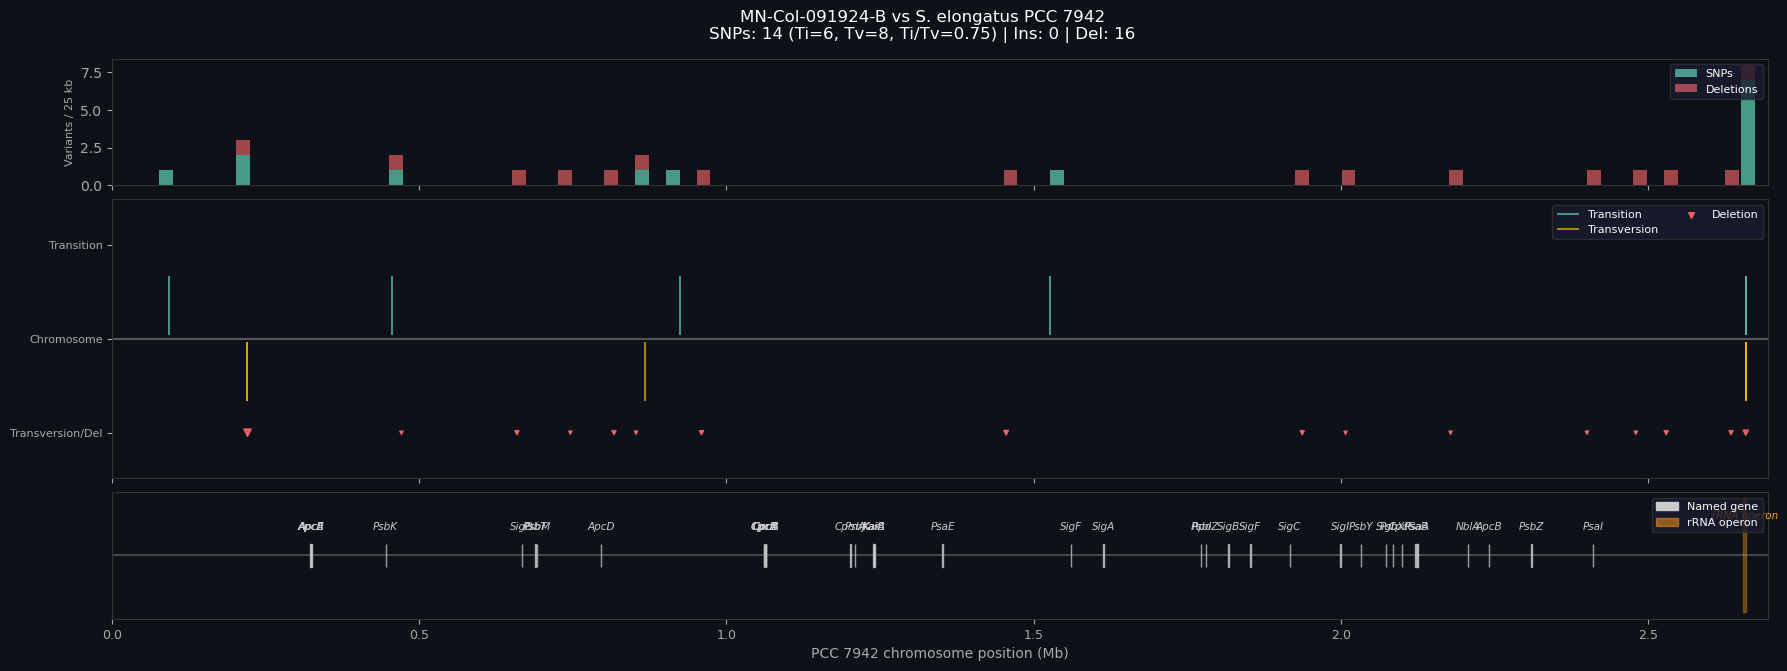

Saved → MN-Col-091924-B_vs_PCC7942_linear_variants.pdf


In [129]:
# ── 7a. Linear variant + gene track ──────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

Mb = 1_000_000
C  = {'ts':'#5BC8AF', 'tv':'#E8B400',
      'ins':'#7EC8E3', 'del':'#FF6B6B', 'rrna':'#FF9F1C'}
BG = '#0e1117'

fig = plt.figure(figsize=(18, 7), facecolor=BG)
gs  = gridspec.GridSpec(3, 1, height_ratios=[1, 2.2, 1.0],
                        hspace=0.08, left=0.05, right=0.97, top=0.90, bottom=0.10)
ax_d = fig.add_subplot(gs[0])
ax_v = fig.add_subplot(gs[1], sharex=ax_d)
ax_g = fig.add_subplot(gs[2], sharex=ax_d)

for ax in [ax_d, ax_v, ax_g]:
    ax.set_facecolor(BG)
    ax.tick_params(colors='#aaa')
    ax.spines[:].set_color('#333')

# ── Panel 1: density histogram ────────────────────────────────────────────────
bc = np.arange(n_bins) * BIN_SIZE + BIN_SIZE / 2
ax_d.bar(bc, snp_bins,   width=BIN_SIZE*0.9, color=C['ts'],  alpha=0.75, label='SNPs')
ax_d.bar(bc, del_bins,   width=BIN_SIZE*0.9, color=C['del'], alpha=0.6,
         bottom=snp_bins, label='Deletions')
ax_d.set_ylabel('Variants / 25 kb', color='#aaa', fontsize=8)
ax_d.legend(fontsize=8, facecolor='#1a1a2e', edgecolor='#333',
            labelcolor='white', loc='upper right')
ax_d.set_xlim(0, CHR_LEN)

# ── Panel 2: individual variant marks ────────────────────────────────────────
chr_df = df_snps[df_snps['chrom'] == CHR_ACC] if len(df_snps) else df_snps
if len(chr_df):
    ts_p = chr_df[chr_df['var_type']=='transition']['pos'].values - 1
    tv_p = chr_df[chr_df['var_type']=='transversion']['pos'].values - 1
    ax_v.vlines(ts_p,  0.05, 0.90, color=C['ts'], lw=1.2, alpha=0.85, label='Transition')
    ax_v.vlines(tv_p, -0.90,-0.05, color=C['tv'], lw=1.2, alpha=0.85, label='Transversion')
if len(del_pos):
    sz = np.clip(np.log1p(del_len)*8, 5, 55)
    ax_v.scatter(del_pos-1, -np.ones(len(del_pos))*1.35, marker='v',
                 s=sz, color=C['del'], alpha=0.85, zorder=3, label='Deletion')

ax_v.axhline(0, color='#555', lw=1.5)
ax_v.set_ylim(-2, 2)
ax_v.set_yticks([-1.35, 0, 1.35])
ax_v.set_yticklabels(['Transversion/Del', 'Chromosome', 'Transition'],
                     color='#aaa', fontsize=8)
ax_v.legend(fontsize=8, facecolor='#1a1a2e', edgecolor='#333',
            labelcolor='white', loc='upper right', ncol=2)

# Gene-name annotations on variant panel (transitions above, transversions below)
labeled_x = []
seen_lbls  = set()
if len(chr_df):
    to_label = chr_df[chr_df['gene_label'].apply(
        lambda x: bool(x) and not str(x).startswith('Synpcc7942')
    )].sort_values('pos')
    for _, row in to_label.iterrows():
        lbl = row['gene_label']
        if lbl in seen_lbls: continue
        if any(abs(row['pos']-1-lx) < 60_000 for lx in labeled_x): continue
        seen_lbls.add(lbl); labeled_x.append(row['pos']-1)
        y_arrow = 0.92 if row['var_type'] == 'transition' else -0.92
        y_text  = 1.72 if row['var_type'] == 'transition' else -1.72
        ax_v.annotate(lbl, xy=(row['pos']-1, y_arrow), xytext=(row['pos']-1, y_text),
                      fontsize=7.5, color='white', ha='center', va='center',
                      arrowprops=dict(arrowstyle='-', color='#666', lw=0.7), zorder=5)

# ── Panel 3: landmark gene track (named genes + rRNA operon only) ─────────────
ax_g.set_ylim(-1, 1)
ax_g.axhline(0, color='#444', lw=1.5, zorder=0)
ax_g.set_yticks([])
ax_g.set_yticklabels([])

# rRNA operon span
RRNA_START, RRNA_END = 2_655_234, 2_660_332
ax_g.axvspan(RRNA_START, RRNA_END, ymin=0.05, ymax=0.95,
             color=C['rrna'], alpha=0.35, zorder=1)
ax_g.text((RRNA_START+RRNA_END)/2, 0.62, 'rRNA operon',
          ha='center', va='center', color=C['rrna'],
          fontsize=7.5, fontstyle='italic', zorder=3)

# Named genes — single row, neutral color, labels above
GENE_COL = '#CCCCCC'
named = [g for g in genes if g['label']]
for g in named:
    w = g['end'] - g['start']
    ax_g.add_patch(mpatches.Rectangle(
        (g['start'], -0.18), w, 0.36,
        color=GENE_COL, alpha=0.75, zorder=2))
    ax_g.text((g['start']+g['end'])/2, 0.38, g['label'],
              ha='center', va='bottom', color=GENE_COL,
              fontsize=7.5, fontstyle='italic', zorder=3)

ax_g.legend(handles=[
    mpatches.Patch(color=GENE_COL,  label='Named gene'),
    mpatches.Patch(color=C['rrna'], alpha=0.5, label='rRNA operon'),
], fontsize=8, facecolor='#1a1a2e', edgecolor='#333',
   labelcolor='white', loc='upper right')

ax_g.set_xlabel('PCC 7942 chromosome position (Mb)', color='#aaa', fontsize=10)
xt = np.arange(0, CHR_LEN+1, 500_000)
ax_g.set_xticks(xt)
ax_g.set_xticklabels([f'{x/Mb:.1f}' for x in xt], color='#aaa', fontsize=9)
plt.setp(ax_d.get_xticklabels(), visible=False)
plt.setp(ax_v.get_xticklabels(), visible=False)

ti_n = (chr_df['var_type']=='transition').sum() if len(chr_df) else 0
tv_n = (chr_df['var_type']=='transversion').sum() if len(chr_df) else 0
fig.suptitle(
    f'{SAMPLE} vs S. elongatus PCC 7942\n'
    f'SNPs: {len(snp_pos):,} (Ti={ti_n}, Tv={tv_n}, Ti/Tv={ti_n/max(tv_n,1):.2f})' 
    f' | Ins: {len(ins_pos):,} | Del: {len(del_pos):,}',
    color='white', fontsize=12, y=0.97)

out = FIG_DIR / f'{SAMPLE}_vs_PCC7942_linear_variants.pdf'
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor=BG)
plt.savefig(out.with_suffix('.png'), dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Saved → {out.name}')


### 7b: Circular variant density

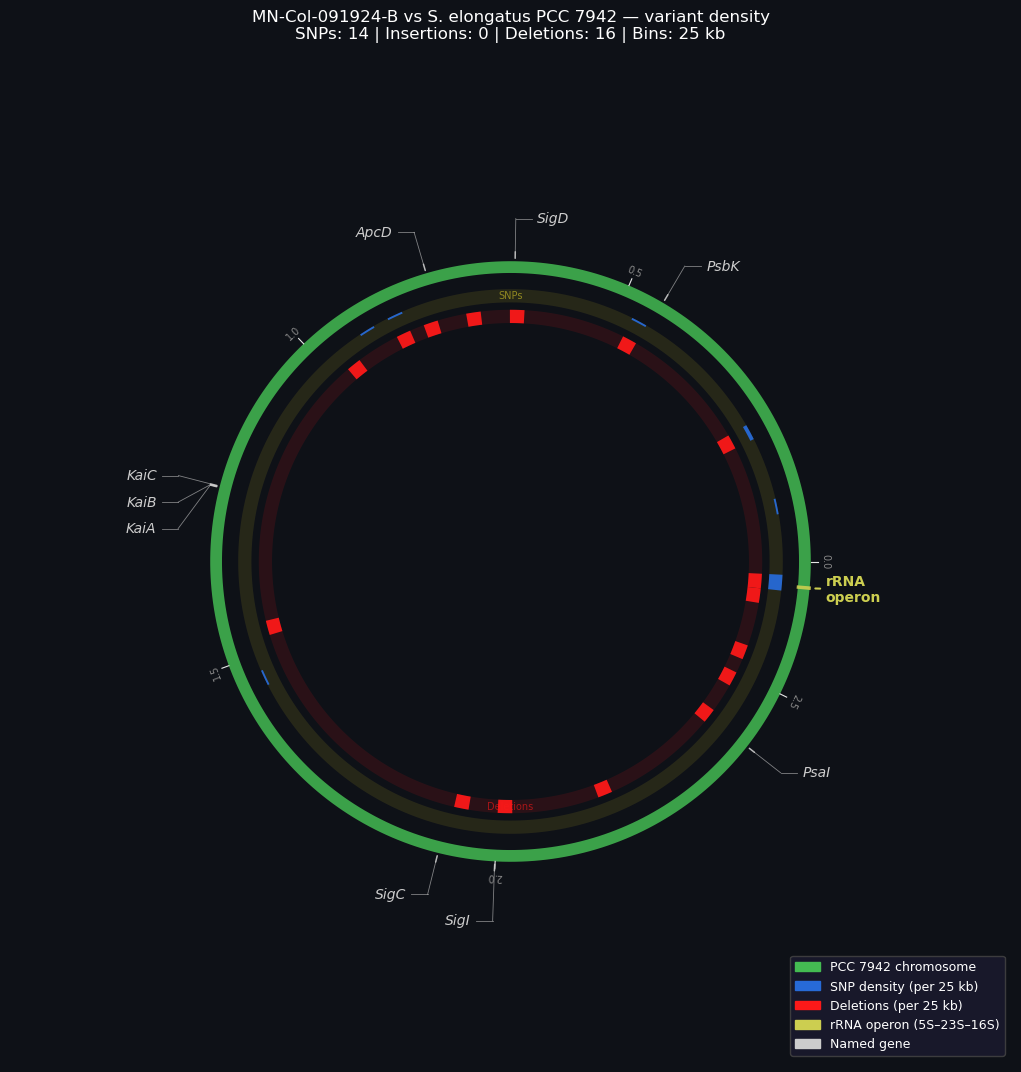

Saved → MN-Col-091924-B_vs_PCC7942_circular_density.pdf


In [113]:
# ── 7b. Circular variant density — external pointer labels ───────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Ring geometry (from outside in) ──────────────────────────────────────────
#   Chromosome ring  : R=1.00, half-width 0.020
#   SNP ring         : outer baseline 0.920, band width 0.045, bars grow inward
#   Deletion ring    : outer baseline 0.850, band width 0.045, bars grow inward
#   Gap / empty      : everything inside ~0.805
R_CHR    = 1.000
TRACK_W  = 0.040

R_SNP_OUT = 0.925
SNP_BW    = 0.045

R_DEL_OUT = 0.855
DEL_BW    = 0.045

BG = '#0e1117'

fig, ax = plt.subplots(figsize=(13, 13))
ax.set_aspect('equal'); ax.axis('off')
ax.set_xlim(-1.7, 1.7); ax.set_ylim(-1.7, 1.7)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)

def ang(pos):
    return (pos / CHR_LEN) * 2 * np.pi

def arc_pts(a0, a1, r, n=200):
    """Points along an arc from a0 to a1 at radius r.
    Always sweeps in the direction specified (a1 may be < a0 for clockwise)."""
    a = np.linspace(a0, a1, n)
    return np.column_stack([r*np.cos(a), r*np.sin(a)])

def draw_ring(r_out, r_in, color, alpha=0.13):
    """Faint background annulus. Inner circle wound clockwise to create a hole."""
    t = np.linspace(0, 2*np.pi, 300)
    outer = np.column_stack([r_out*np.cos(t), r_out*np.sin(t)])
    inner = np.column_stack([r_in*np.cos(t[::-1]), r_in*np.sin(t[::-1])])
    ax.fill(*np.vstack([outer, inner]).T, color=color, alpha=alpha, lw=0)

def draw_bar(a0, a1, r_out, h, color, alpha=0.95):
    """Filled arc wedge from r_out inward by h."""
    # outer arc: counterclockwise a0→a1; inner arc: clockwise a1→a0
    if a1 < a0: a1 += 2*np.pi
    t_fwd = np.linspace(a0, a1, max(int((a1-a0)*120), 3))
    t_bwd = t_fwd[::-1]
    outer = np.column_stack([(r_out)*np.cos(t_fwd), (r_out)*np.sin(t_fwd)])
    inner = np.column_stack([(r_out - h)*np.cos(t_bwd), (r_out - h)*np.sin(t_bwd)])
    ax.fill(*np.vstack([outer, inner]).T, color=color, alpha=alpha, lw=0)

# ── Chromosome ring ───────────────────────────────────────────────────────────
draw_ring(R_CHR + TRACK_W/2, R_CHR - TRACK_W/2, '#44BB52', alpha=0.85)

# ── Mb tick marks ─────────────────────────────────────────────────────────────
R_TICK_OUT = R_CHR + TRACK_W/2
for pos in range(0, CHR_LEN, 500_000):
    a = ang(pos)
    r0, r1 = R_TICK_OUT, R_TICK_OUT + 0.025
    ax.plot([r0*np.cos(a), r1*np.cos(a)],
            [r0*np.sin(a), r1*np.sin(a)], color='white', lw=0.8, alpha=0.9)
    ax.text((r1+0.025)*np.cos(a), (r1+0.025)*np.sin(a),
            f'{pos/1e6:.1f}', ha='center', va='center',
            color='#888', fontsize=7,
            rotation=np.degrees(a) % 360 - 90)

# ── SNP ring ──────────────────────────────────────────────────────────────────
draw_ring(R_SNP_OUT, R_SNP_OUT - SNP_BW, '#D7C827', alpha=0.12)
snp_max   = max(snp_bins.max(), 1)
snp_scale = SNP_BW / snp_max
for b in range(n_bins):
    if snp_bins[b] == 0: continue
    a0 = ang(b * BIN_SIZE)
    a1 = ang(min((b+1) * BIN_SIZE, CHR_LEN))
    draw_bar(a0, a1, R_SNP_OUT, snp_bins[b]*snp_scale, '#276AD7')

# ── Deletion ring ─────────────────────────────────────────────────────────────
draw_ring(R_DEL_OUT, R_DEL_OUT - DEL_BW, '#FC1919', alpha=0.12)
del_max   = max(del_bins.max(), 1)
del_scale = DEL_BW / del_max
for b in range(n_bins):
    if del_bins[b] == 0: continue
    a0 = ang(b * BIN_SIZE)
    a1 = ang(min((b+1) * BIN_SIZE, CHR_LEN))
    draw_bar(a0, a1, R_DEL_OUT, del_bins[b]*del_scale, '#FC1919')

# ── Ring labels ───────────────────────────────────────────────────────────────
ax.text(0,  (R_SNP_OUT - SNP_BW/2), 'SNPs',
        ha='center', va='center', color='#D7C827', fontsize=7, alpha=0.6)
ax.text(0, -(R_DEL_OUT - DEL_BW/2), 'Deletions',
        ha='center', va='center', color='#FC1919', fontsize=7, alpha=0.6)

# ── rRNA operon arc (5S–23S–tRNAs–16S cluster) ───────────────────────────────
# 5S: 2,655,234  16S end: 2,660,332  — highlight full operon on chromosome ring
RRNA_START = 2_655_234
RRNA_END   = 2_660_332
a_r0 = ang(RRNA_START)
a_r1 = ang(RRNA_END)
po = arc_pts(a_r0, a_r1, R_CHR + TRACK_W/2 + 0.004)
pi = arc_pts(a_r1, a_r0, R_CHR - TRACK_W/2 - 0.004)
ax.fill(*np.vstack([po, pi]).T, color='#CCCE50', alpha=0.90, lw=0)

# Label: small pointer just outside the arc midpoint
a_mid = ang((RRNA_START + RRNA_END) / 2)
r_lbl = R_CHR + TRACK_W/2 + 0.055
ax.annotate('rRNA\noperon',
            xy=(( R_CHR + TRACK_W/2 + 0.010)*np.cos(a_mid),
                ( R_CHR + TRACK_W/2 + 0.010)*np.sin(a_mid)),
            xytext=(r_lbl*np.cos(a_mid), r_lbl*np.sin(a_mid)),
            arrowprops=dict(arrowstyle='-', color='#CCCE50', lw=1.5),
            color='#CCCE50', fontsize=10, fontweight='bold', ha='left', va='center')

# ── External gene pointer labels ──────────────────────────────────────────────
KAI_ALWAYS  = {'KaiA', 'KaiB', 'KaiC'}
PROXIMITY   = 25_000
all_var_pos = np.concatenate([snp_pos, ins_pos, del_pos]) if (len(snp_pos)+len(ins_pos)+len(del_pos)) else np.array([])

def near_variant(g):
    if not len(all_var_pos): return False
    mid = (g['start'] + g['end']) / 2
    return bool(np.any(np.abs(all_var_pos - mid) <= PROXIMITY))

named_genes = [g for g in genes
               if g['label'] and (g['label'] in KAI_ALWAYS or near_variant(g))]

R_GENE_TICK = R_TICK_OUT + 0.010
R_LEADER    = 1.165
SHELF       = 0.055
MIN_SEP     = 0.090

items = sorted(
    [(ang((g['start']+g['end'])/2), g['label'], '#CCCCCC')
     for g in named_genes],
    key=lambda x: x[0]
)

def spread(half_items, direction):
    key_fn = lambda x: R_LEADER * np.sin(x[0])
    if direction == 'right':
        half_items = sorted(half_items, key=key_fn)
        last_y = -1.55
    else:
        half_items = sorted(half_items, key=key_fn, reverse=True)
        last_y = +1.55
    out = []
    for a, lbl, col in half_items:
        y_nat = R_LEADER * np.sin(a)
        y = max(y_nat, last_y + MIN_SEP) if direction == 'right' else min(y_nat, last_y - MIN_SEP)
        last_y = y
        out.append((a, lbl, col, y))
    return out

right = spread([(a,l,c) for a,l,c in items if np.cos(a) >= 0], 'right')
left  = spread([(a,l,c) for a,l,c in items if np.cos(a) <  0], 'left')

for a, lbl, col, y_adj in right + left:
    on_right = np.cos(a) >= 0
    ha   = 'left' if on_right else 'right'
    sign =  1      if on_right else -1

    ax.plot([R_GENE_TICK*np.cos(a), (R_GENE_TICK+0.022)*np.cos(a)],
            [R_GENE_TICK*np.sin(a), (R_GENE_TICK+0.022)*np.sin(a)],
            color=col, lw=1.1, alpha=0.9, solid_capstyle='round')
    x_elbow = R_LEADER * np.cos(a)
    ax.plot([(R_GENE_TICK+0.022)*np.cos(a), x_elbow],
            [(R_GENE_TICK+0.022)*np.sin(a), y_adj],
            color=col, lw=0.6, alpha=0.6)
    x_shelf = x_elbow + sign * SHELF
    ax.plot([x_elbow, x_shelf], [y_adj, y_adj], color=col, lw=0.6, alpha=0.6)
    ax.text(x_shelf + sign*0.018, y_adj, lbl,
            ha=ha, va='center', color=col, fontsize=10, fontstyle='italic')

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [
    mpatches.Patch(color='#44BB52', label='PCC 7942 chromosome'),
    mpatches.Patch(color="#276AD7", label='SNP density (per 25 kb)'),
    mpatches.Patch(color='#FC1919', label='Deletions (per 25 kb)'),
    mpatches.Patch(color='#CCCE50', label='rRNA operon (5S–23S–16S)'),
    mpatches.Patch(color='#CCCCCC', label='Named gene'),
]
ax.legend(handles=handles, loc='lower right', fontsize=9,
          facecolor='#1a1a2e', edgecolor='#444', labelcolor='white',
          framealpha=0.85)

ax.set_title(
    f'{SAMPLE} vs S. elongatus PCC 7942 — variant density\n'
    f'SNPs: {len(snp_pos):,} | Insertions: {len(ins_pos):,} | '
    f'Deletions: {len(del_pos):,} | Bins: 25 kb',
    color='white', fontsize=12, pad=16)

out = FIG_DIR / f'{SAMPLE}_vs_PCC7942_circular_density.pdf'
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor=BG)
plt.savefig(out.with_suffix('.png'), dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Saved → {out.name}')


### 7c: Variant catalogue — plot table

/var/folders/cr/9y9g3zs15tn8hr54m5nn72200000gn/T/ipykernel_80558/374522218.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3)


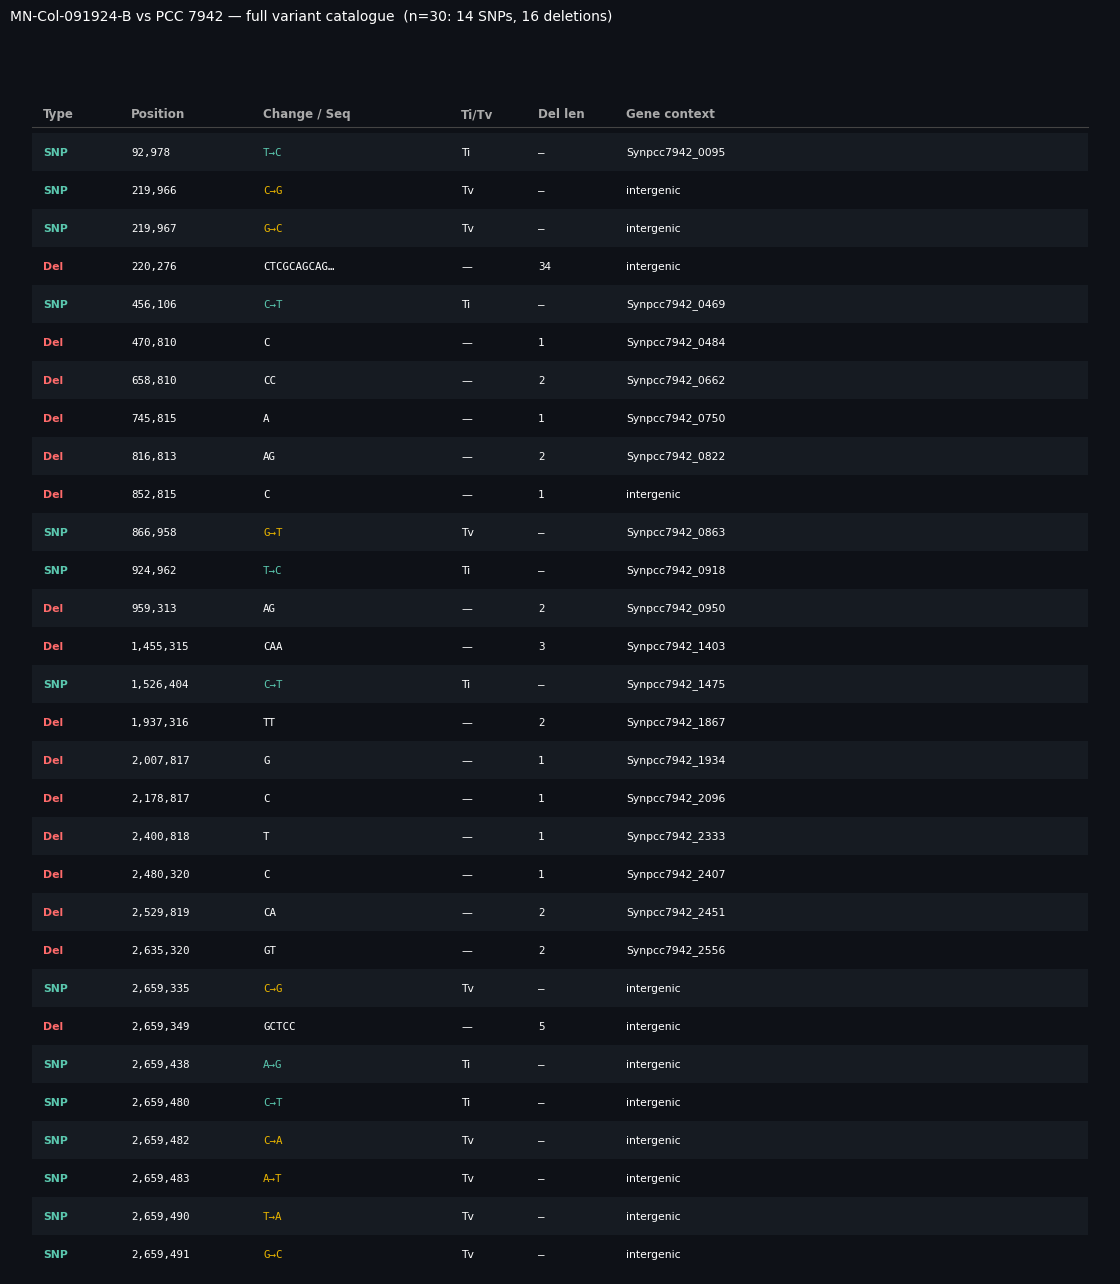

Saved → variant_catalogue.pdf


In [133]:
# ── 7c. Variant catalogue as a figure table ───────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

BG = '#0e1117'

# ── Build rows ────────────────────────────────────────────────────────────────
rows = []

for _, r in df_snps[df_snps['chrom']==CHR_ACC].sort_values('pos').iterrows():
    g    = gene_at(int(r['pos']))
    ctx  = (g.get('label') or g.get('locus', 'intergenic')) if g else 'intergenic'
    change = f"{r['ref']}→{r['alt']}"
    ti_tv  = 'Ti' if r['var_type'] == 'transition' else 'Tv'
    rows.append(['SNP', f"{int(r['pos']):,}", change, ti_tv, '—', ctx])

for _, r in chr_del.sort_values('pos').iterrows():
    g    = gene_at(int(r['pos']))
    ctx  = (g.get('label') or g.get('locus', 'intergenic')) if g else 'intergenic'
    seq  = r['seq'] if len(r['seq']) <= 12 else r['seq'][:10] + '…'
    rows.append(['Del', f"{int(r['pos']):,}", seq, '—', str(int(r['len'])), ctx])

# sort all rows by position (strip commas for numeric sort)
rows.sort(key=lambda x: int(x[1].replace(',', '')))

COL_HEADERS = ['Type', 'Position', 'Change / Seq', 'Ti/Tv', 'Del len', 'Gene context']
COL_WIDTHS  = [0.08,    0.12,       0.18,           0.07,    0.08,      0.20]

TYPE_COLOR = {'SNP': '#5BC8AF', 'Del': '#FF6B6B'}

n_rows = len(rows)
row_h  = 0.38          # inches per row
fig_h  = 1.0 + n_rows * row_h
fig    = plt.figure(figsize=(11, fig_h), facecolor=BG)
ax     = fig.add_axes([0, 0, 1, 1])
ax.set_facecolor(BG)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# column x positions
x_starts = []
x = 0.03
for w in COL_WIDTHS:
    x_starts.append(x)
    x += w

header_y  = 1 - 0.8 / fig_h
stripe_h  = row_h / fig_h
first_row_y = header_y - stripe_h

# Header
for xi, (lbl, xs) in enumerate(zip(COL_HEADERS, x_starts)):
    ax.text(xs, header_y, lbl, color='#aaaaaa', fontsize=8.5,
            fontweight='bold', va='center', transform=ax.transAxes)

ax.plot([0.02, 0.98], [header_y - stripe_h*0.35, header_y - stripe_h*0.35],
        color='#444', lw=0.8, transform=ax.transAxes, zorder=2)

# Data rows
for ri, row in enumerate(rows):
    y = first_row_y - ri * stripe_h
    # alternating stripe
    stripe_col = '#161b22' if ri % 2 == 0 else '#0e1117'
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.02, y - stripe_h*0.5), 0.96, stripe_h,
        boxstyle='square,pad=0', facecolor=stripe_col,
        edgecolor='none', transform=ax.transAxes, zorder=0))

    for ci, (val, xs) in enumerate(zip(row, x_starts)):
        color = 'white'
        fw    = 'normal'
        if ci == 0:                   # Type column — colored
            color = TYPE_COLOR.get(val, 'white')
            fw    = 'bold'
        elif ci == 2 and row[0] == 'SNP':  # Change col for SNPs — monospace-ish
            color = '#E8B400' if row[3] == 'Tv' else '#5BC8AF'
        ax.text(xs, y, val, color=color, fontsize=7.8, va='center',
                fontweight=fw, transform=ax.transAxes, zorder=1,
                fontfamily='monospace' if ci in (1, 2, 4) else 'sans-serif')

ax.set_title(
    f'MN-Col-091924-B vs PCC 7942 — full variant catalogue  '
    f'(n={len(rows)}: {(df_snps["chrom"]==CHR_ACC).sum()} SNPs, {len(chr_del)} deletions)',
    color='white', fontsize=10, pad=10, loc='left')

plt.tight_layout(pad=0.3)
out = FIG_DIR / 'variant_catalogue.pdf'
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor=BG)
plt.savefig(out.with_suffix('.png'), dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Saved → {out.name}')


### Co-occurring variant bins

Identifies 25 kb bins that contain both at least one SNP and at least one deletion. Visual overlap on the circular plot does not guarantee the variants are adjacent — this cell prints exact positions and gene context so they can be evaluated individually.

In [95]:
for b in range(n_bins):
    if snp_bins[b] > 0 and del_bins[b] > 0:
        b_start = b * BIN_SIZE
        b_end   = (b+1) * BIN_SIZE
        snps_here = chr_snps[(chr_snps['pos'] >= b_start) & (chr_snps['pos'] < b_end)]
        dels_here = chr_del[(chr_del['pos']  >= b_start) & (chr_del['pos']  < b_end)]
        print(f'\nBin {b} ({b_start/1e6:.3f}–{b_end/1e6:.3f} Mb)')
        print('  SNPs:', snps_here[['pos','ref','alt']].to_string(index=False))
        print('  DELs:', dels_here[['pos','len']].to_string(index=False))
        g = gene_at(snps_here['pos'].iloc[0])
        print('  Gene:', g['locus'] if g else 'intergenic', '|', (g or {}).get('product',''))


Bin 8 (0.200–0.225 Mb)
  SNPs:    pos ref alt
219966   C   G
219967   G   C
  DELs:    pos  len
220276   34
  Gene: intergenic | 

Bin 18 (0.450–0.475 Mb)
  SNPs:    pos ref alt
456106   C   T
  DELs:    pos  len
470810    1
  Gene: Synpcc7942_0469 | phosphoglycerate mutase

Bin 34 (0.850–0.875 Mb)
  SNPs:    pos ref alt
866958   G   T
  DELs:    pos  len
852815    1
  Gene: Synpcc7942_0863 | conserved hypothetical protein

Bin 106 (2.650–2.675 Mb)
  SNPs:     pos ref alt
2659335   C   G
2659438   A   G
2659480   C   T
2659482   C   A
2659483   A   T
2659490   T   A
2659491   G   C
  DELs:     pos  len
2659349    5
  Gene: intergenic | 


### rRNA locus — flanking gene context

The highest-density variant bin (Bin 106, 2.650–2.675 Mb) falls within the rRNA operon. This cell lists all CDS features within ±10 kb to identify what flanks the operon.

In [97]:
flank_start = 2_650_000
flank_end   = 2_670_000
nearby = [g for g in genes if g['end'] >= flank_start and g['start'] <= flank_end]
for g in nearby:
    print(f"{g['start']:>9,}–{g['end']:<9,}  {'+' if g['strand']==1 else '-'}  "
          f"{g['locus']}  {g['product'][:60]}")


2,648,823–2,650,032  -  Synpcc7942_2570  tyrosyl-tRNA synthetase
2,650,101–2,651,979  +  Synpcc7942_2571  Penicillin-binding protein 1A
2,652,059–2,652,377  -  Synpcc7942_2572  conserved hypothetical protein
2,652,515–2,653,346  -  Synpcc7942_2573  manganese transport system membrane protein MntB
2,653,346–2,654,102  -  Synpcc7942_2574  ATPase
2,654,162–2,655,104  +  Synpcc7942_2575  Mn transporter MntC
2,660,595–2,662,110  -  Synpcc7942_2576  conserved hypothetical protein
2,662,168–2,663,092  -  Synpcc7942_2577  Glucokinase regulatory-like protein
2,663,092–2,663,566  -  Synpcc7942_2578  conserved hypothetical protein
2,663,565–2,664,450  -  Synpcc7942_2579  Heat shock protein DnaJ-like
2,664,459–2,666,709  -  Synpcc7942_2580  Heat shock protein Hsp70
2,667,017–2,667,386  +  Synpcc7942_2581  Ferredoxin (2Fe-2S)
2,667,389–2,668,211  +  Synpcc7942_2582  myo-inositol-1(or 4)-monophosphatase
2,668,298–2,668,931  +  Synpcc7942_2583  conserved hypothetical protein
2,668,940–2,669,705  +  S

### rRNA locus — all annotated features

Lists every feature type (rRNA, tRNA, repeat regions, etc.) in the 2.655–2.661 Mb window to confirm that the variant cluster sits inside the 16S rRNA gene rather than in an intergenic or coding region.

In [98]:
# Check ALL feature types in the gap, not just CDS
for feat in gbk_rec.features:
    s = int(feat.location.start)
    e = int(feat.location.end)
    if e >= 2_655_000 and s <= 2_661_000 and feat.type != 'gene':
        print(f"{s:>9,}–{e:<9,}  {feat.type:15s}  "
              f"{feat.qualifiers.get('product', feat.qualifiers.get('note', ['']))[0][:60]}")


        0–2,695,903  source           
2,654,162–2,655,104  CDS              Mn transporter MntC
2,655,234–2,655,349  rRNA             5S ribosomal RNA
2,655,419–2,658,297  rRNA             23S ribosomal RNA
2,658,498–2,658,574  tRNA             tRNA-Ala
2,658,604–2,658,681  tRNA             tRNA-Ile
2,658,842–2,660,332  rRNA             16S ribosomal RNA
2,660,595–2,662,110  CDS              conserved hypothetical protein


### Insertion artifact investigation

The following three cells were used to diagnose the single insertion detected by cs-tag parsing. **Cell 24** checks the reference sequence context for homopolymer runs. **Cell 25** runs `samtools mpileup` at the insertion site to count raw-read support. **Cell 26** checks whether the position falls inside a CDS.

> **Conclusion:** non-homopolymer context, 0/219 raw-read support, intergenic position → confirmed Flye mis-assembly, removed in the artifact-removal cell above.

In [71]:
# Reference context around the insertion
ins_row = df_ins[df_ins['chrom'] == CHR_ACC].iloc[0]
pos = ins_row['pos']          # 1-based
ins_seq = ins_row.get('alt', '?')

ref_seq = str(gbk_rec.seq)
window = ref_seq[pos-15:pos+15]   # 30-bp window centered on insertion
print(f"Insertion: pos={pos}, seq={ins_seq}, len={ins_row['len']}")
print(f"Reference context: ...{window}...")
print(f"Homopolymer? {any(window[14]*3 in window for _ in [0])}")


Insertion: pos=2659349, seq=?, len=7
Reference context: ...CCACCTGTCTCCCCGCTCCCGAAGGCACTC...
Homopolymer? False


In [73]:
import subprocess
result = subprocess.run(
    ['samtools', 'mpileup', '-r', f'CP000100.1:{pos}-{pos}',
     '--reference', str(REF_FA),
     str(OUT_DIR / 'mapped.sorted.bam')],
    capture_output=True, text=True)
print(result)

CompletedProcess(args=['samtools', 'mpileup', '-r', 'CP000100.1:2659349-2659349', '--reference', '/Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/ref/PCC7942_reference.fasta', '/Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/15_env7942/mapped.sorted.bam'], returncode=1, stdout='', stderr='[E::hts_open_format] Failed to open file "/Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/15_env7942/mapped.sorted.bam" : No such file or directory\n[mpileup] failed to open /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/15_env7942/mapped.sorted.bam: No such file or directory\n')


In [74]:
g = gene_at(pos)
print(g['locus'] if g else 'intergenic')
print(g['product'] if g else '')

intergenic



### Targeted follow-up: three regions of interest

After reviewing the variant plots, three genomic regions warranted closer inspection:

1. **Bin 8 (pos 219,966–220,276):** dinucleotide swap + 34 bp deletion flanking a small PCP reductase gene, upstream of MinD (cell division inhibitor)
2. **Bin 18 (pos 470,810):** 1 bp deletion near a phosphoglycerate mutase — check if it falls inside a CDS (frameshift risk)
3. **KaiABC:** circadian clock genes are labelled on the plot by convention; confirm whether any variants actually fall nearby

In [120]:
# ── Targeted follow-up: three regions of interest ────────────────────────────

# 1. Gene context of the 34 bp intergenic deletion (Bin 8, pos 220,276)
print("=" * 60)
print("1. Flanking genes around 34 bp deletion at pos 220,276")
print("=" * 60)
for feat in gbk_rec.features:
    s = int(feat.location.start)
    e = int(feat.location.end)
    if e >= 219_000 and s <= 222_000 and feat.type not in ('source', 'gene'):
        strand = '+' if feat.location.strand == 1 else '-'
        prod = feat.qualifiers.get('product', feat.qualifiers.get('note', ['']))[0]
        locus = feat.qualifiers.get('locus_tag', [''])[0]
        print(f"  {s:>9,}–{e:<9,}  {feat.type:8s}  {strand}  {locus:20s}  {prod[:50]}")
print(f"  Deletion: pos=220,276  len=34 bp  (intergenic)")
print(f"  Adjacent SNPs: 219,966 C→G  and  219,967 G→C  (dinucleotide swap)")

# 2. Gene at the 1 bp deletion in Bin 18 (pos 470,810)
print()
print("=" * 60)
print("2. Gene context of 1 bp deletion at pos 470,810 (Bin 18)")
print("=" * 60)
g = gene_at(470_810)
if g:
    print(f"  Falls inside: {g['locus']}  ({g['start']:,}–{g['end']:,})")
    print(f"  Product: {g['product']}")
    print(f"  Strand: {g['strand']}")
    offset = 470_810 - g['start']
    print(f"  Offset into CDS: {offset} bp  →  codon {offset//3 + 1}")
    print(f"  This is a FRAMESHIFT if in-frame and not compensated.")
else:
    print("  Intergenic.")

# 3. KaiABC proximity to variants
print()
print("=" * 60)
print("3. Nearest variants to KaiA / KaiB / KaiC")
print("=" * 60)
kai_genes = [g for g in genes if g['label'] in {'KaiA', 'KaiB', 'KaiC'}]
all_variants = (
    [(p, 'SNP')    for p in snp_pos] +
    [(p, 'INS')    for p in ins_pos] +
    [(p, 'DEL')    for p in del_pos]
)
for kg in sorted(kai_genes, key=lambda x: x['start']):
    mid = (kg['start'] + kg['end']) / 2
    dists = [(abs(p - mid), p, t) for p, t in all_variants]
    nearest = sorted(dists)[:3]
    print(f"  {kg['label']}  ({kg['start']:,}–{kg['end']:,})")
    for dist, pos, vtype in nearest:
        print(f"    nearest {vtype}: pos={pos:,}  distance={dist/1e3:.1f} kb")


1. Flanking genes around 34 bp deletion at pos 220,276
    219,112–219,871    CDS       +  Synpcc7942_0217       phosphatases-like
    219,926–220,000    tRNA      +  Synpcc7942_R0029      tRNA-Pro
    220,023–220,191    CDS       -  Synpcc7942_0218       conserved hypothetical protein
    220,315–220,636    CDS       -  Synpcc7942_0219       conserved hypothetical protein
    220,638–221,397    CDS       -  Synpcc7942_0220       probable cell division inhibitor MinD
    221,497–222,535    CDS       +  Synpcc7942_0221       glucokinase
  Deletion: pos=220,276  len=34 bp  (intergenic)
  Adjacent SNPs: 219,966 C→G  and  219,967 G→C  (dinucleotide swap)

2. Gene context of 1 bp deletion at pos 470,810 (Bin 18)
  Falls inside: Synpcc7942_0484  (469,431–470,874)
  Product: conserved hypothetical protein
  Strand: -1
  Offset into CDS: 1379 bp  →  codon 460
  This is a FRAMESHIFT if in-frame and not compensated.

3. Nearest variants to KaiA / KaiB / KaiC
  KaiC  (1,238,549–1,240,109)
    nea

### Homopolymer check — 1 bp deletion at pos 470,810

ONT sequencing has an elevated error rate in homopolymer runs (≥4 of the same base). A 1 bp deletion inside a homopolymer run should be treated as likely sequencing noise until confirmed by an independent method.

In [121]:
# ── Next step 1: Homopolymer context of 1 bp deletion at pos 470,810 ─────────
DEL_POS = 470_810
ref_seq = str(gbk_rec.seq)
win = ref_seq[DEL_POS - 16 : DEL_POS + 15]   # 30 bp window, 0-based
deleted_base = ref_seq[DEL_POS - 1]           # the deleted base (1-based)

print(f"Deleted base : {deleted_base}")
print(f"Reference context (±15 bp):")
print(f"  ...{win}...")
print(f"       {'':>15}^ pos {DEL_POS:,}")

# Check for homopolymer run containing the deletion
run_start = DEL_POS - 1
while run_start > 0 and ref_seq[run_start - 1] == deleted_base:
    run_start -= 1
run_end = DEL_POS - 1
while run_end < len(ref_seq) - 1 and ref_seq[run_end + 1] == deleted_base:
    run_end += 1
run_len = run_end - run_start + 1

print(f"\nHomopolymer run of '{deleted_base}': length = {run_len} bp  "
      f"(positions {run_start+1:,}–{run_end+1:,})")
if run_len >= 4:
    print("  ⚠  Run length ≥ 4 — treat as likely ONT homopolymer error until confirmed.")
elif run_len >= 3:
    print("  ~  Run length 3 — borderline; worth checking pileup support.")
else:
    print("  ✓  No homopolymer run — deletion is likely real.")


Deleted base : C
Reference context (±15 bp):
  ...TTGCCCATCAAGAGGCAGGCCAGCAGAGACA...
                      ^ pos 470,810

Homopolymer run of 'C': length = 1 bp  (positions 470,810–470,810)
  ✓  No homopolymer run — deletion is likely real.


### BLAST unknown proteins against NCBI nr

Two locus tags with uninformative annotations are queried against NCBI nr via remote blastp:

- **Synpcc7942_0484** (`conserved hypothetical protein`) — falls near a deletion in Bin 34; may have been characterised since PCC 7942 was annotated in 2006
- **Synpcc7942_0218** (`conserved hypothetical protein`) — bracketed by inverted repeats and flanked by variants in the environmental strain; tested for transposase homology

Results are cached to `results/15_env7942/` — re-running will not hit the network.

In [128]:
# ── Next step 2: BLAST Synpcc7942_0484 protein against UniProt ───────────────
# Uses NCBI blastp via Biopython Entrez qblast (remote, no local DB needed).
# Result cached to results/15_env7942/Synpcc7942_0484_blastp.xml.

from Bio import SeqIO, Entrez
from Bio.Blast import NCBIWWW, NCBIXML
from pathlib import Path
import time

Entrez.email = cfg.get("entrez_email", "palmer.lab@wisc.edu")
LOCUS_QUERY  = "Synpcc7942_0484"
BLAST_CACHE  = OUT_DIR / f"{LOCUS_QUERY}_blastp_nr.xml"  # nr, not swissprot

# Extract CDS translation
prot_seq = None
for feat in gbk_rec.features:
    if feat.type == "CDS":
        if feat.qualifiers.get("locus_tag", [""])[0] == LOCUS_QUERY:
            prot_seq = feat.qualifiers.get("translation", [None])[0]
            product  = feat.qualifiers.get("product", ["?"])[0]
            print(f"Found {LOCUS_QUERY}: {product}")
            print(f"Protein length: {len(prot_seq)} aa")
            break

if prot_seq is None:
    raise ValueError(f"{LOCUS_QUERY} not found in GenBank record")

if not BLAST_CACHE.exists():
    print("Running remote blastp vs nr (1–3 minutes)...")
    result_handle = NCBIWWW.qblast(
        "blastp", "nr", prot_seq,
        hitlist_size=10, expect=1e-3
    )
    with open(BLAST_CACHE, "w") as f:
        f.write(result_handle.read())
    print(f"Cached → {BLAST_CACHE.name}")
else:
    print(f"Using cached result: {BLAST_CACHE.name}")

import pandas as pd
with open(BLAST_CACHE) as f:
    blast_record = NCBIXML.read(f)

rows = []
for aln in blast_record.alignments[:10]:
    hsp = aln.hsps[0]
    rows.append({
        "hit":      aln.title[:90],
        "e_value":  hsp.expect,
        "pct_id":   round(100 * hsp.identities / hsp.align_length, 1),
        "coverage": round(100 * hsp.align_length / blast_record.query_length, 1),
    })

df_blast = pd.DataFrame(rows)
if df_blast.empty:
    print(f"\nNo hits for {LOCUS_QUERY} in nr at e<1e-3 — genuinely novel or too short.")
else:
    print(f"\nTop blastp hits for {LOCUS_QUERY} vs nr:\n")
    print(df_blast.to_string(index=False))


# ── BLAST Synpcc7942_0218 — IS element / transposase check ───────────────────
# This small hypothetical (165 bp, ~55 aa) is bracketed by inverted repeats
# and flanked by variants in the environmental strain — classic IS element signature.
LOCUS_0218   = "Synpcc7942_0218"
BLAST_0218   = OUT_DIR / f"{LOCUS_0218}_blastp.xml"

prot_0218 = None
for feat in gbk_rec.features:
    if feat.type == "CDS":
        if feat.qualifiers.get("locus_tag", [""])[0] == LOCUS_0218:
            prot_0218 = feat.qualifiers.get("translation", [None])[0]
            print(f"Found {LOCUS_0218}: {feat.qualifiers.get('product', ['?'])[0]}")
            print(f"Protein length: {len(prot_0218)} aa")
            break

if prot_0218 is None:
    print(f"{LOCUS_0218} not found in GenBank record")
elif BLAST_0218.exists():
    print(f"Using cached result: {BLAST_0218.name}")
else:
    print("Running remote blastp vs nr (to catch transposases not in Swiss-Prot)...")
    result_handle = NCBIWWW.qblast(
        "blastp", "nr", prot_0218,
        hitlist_size=10, expect=1e-3
    )
    with open(BLAST_0218, "w") as f:
        f.write(result_handle.read())
    print(f"Cached → {BLAST_0218.name}")

if prot_0218 and BLAST_0218.exists():
    with open(BLAST_0218) as f:
        br = NCBIXML.read(f)
    rows = []
    for aln in br.alignments[:10]:
        hsp = aln.hsps[0]
        rows.append({
            "hit":      aln.title[:90],
            "e_value":  hsp.expect,
            "pct_id":   round(100 * hsp.identities / hsp.align_length, 1),
            "coverage": round(100 * hsp.align_length / br.query_length, 1),
        })
    df_0218 = pd.DataFrame(rows)
    print(f"\nTop blastp hits for {LOCUS_0218} vs nr:")
    print(df_0218.to_string(index=False))
    # Flag transposase hits
    hits_text = " ".join(df_0218["hit"].str.lower())
    if any(kw in hits_text for kw in ["transpos", "integrase", "is element", "mobile"]):
        print("\n⚠  Transposase / mobile element hit detected — IS element hypothesis supported.")
    else:
        print("\n✓  No transposase hits — mobile element hypothesis not supported by sequence.")


Found Synpcc7942_0484: conserved hypothetical protein
Protein length: 480 aa
Running remote blastp vs nr (1–3 minutes)...
Cached → Synpcc7942_0484_blastp_nr.xml

Top blastp hits for Synpcc7942_0484 vs nr:

                                                                                       hit  e_value  pct_id  coverage
gb|ABB56516.1| conserved hypothetical protein [Synechococcus elongatus PCC 7942 = FACHB-80      0.0   100.0     100.0
         dbj|BAD79225.1| hypothetical protein syc1035_d [Synechococcus elongatus PCC 6301]      0.0    99.8     100.0
ref|WP_231621350.1| CPBP family intramembrane glutamic endopeptidase [Synechococcus elonga      0.0   100.0      98.8
ref|WP_234701806.1| CPBP family intramembrane glutamic endopeptidase [Synechococcus elonga      0.0    99.8      98.8
ref|WP_238154256.1| CPBP family intramembrane glutamic endopeptidase [Synechococcus elonga      0.0    99.4      98.8
ref|WP_338441459.1| CPBP family intramembrane glutamic endopeptidase [Synechococcus el

### Sequence motif analysis — Bin 8 window (219,951–220,300 bp)

The 350 bp region containing the dinucleotide swap and 34 bp deletion is scanned for:

- **Direct repeats** (≥8 bp) — transposon target site duplications or binding sites
- **Inverted repeats / stem-loops** (≥8 bp) — transcription terminators or regulatory hairpins
- **σ70 −10 and −35 boxes** (TATAAT / TTGACA ± 1 mismatch) — promoter elements on both strands

The window spans two intergenic gaps flanking Synpcc7942_0218 (PCP reductase / protochlorophyllide biosynthesis) and sits ~450 bp upstream of MinD.

In [127]:
# ── Next step 3: 219,966–220,276 window — repeats and motifs upstream of MinD ─
# Inspect raw sequence for direct/inverted repeats, AT-richness (−10/−35 boxes),
# and known cyanobacterial regulatory motifs.

import re
from collections import Counter

ref_seq  = str(gbk_rec.seq)
WIN_START = 219_950   # 0-based (includes a few bp before the dinucleotide swap)
WIN_END   = 220_300   # covers through the 34 bp deletion
window    = ref_seq[WIN_START:WIN_END]

print(f"Window: {WIN_START+1:,}–{WIN_END:,}  ({WIN_END-WIN_START} bp)")
print(f"Sequence:\n  {window}\n")

# Flanking genes
print("Flanking CDS (within ±5 kb):")
for feat in gbk_rec.features:
    s = int(feat.location.start)
    e = int(feat.location.end)
    if e >= WIN_START - 5000 and s <= WIN_END + 5000 and feat.type == "CDS":
        strand  = "+" if feat.location.strand == 1 else "-"
        locus   = feat.qualifiers.get("locus_tag", [""])[0]
        product = feat.qualifiers.get("product",   [""])[0]
        dist_to_window = max(0, WIN_START - e) if e < WIN_START else max(0, s - WIN_END)
        print(f"  {s+1:>9,}–{e:<9,}  {strand}  {locus:20s}  {product[:50]}"
              f"  (gap={dist_to_window:,} bp)")

# AT content (proxy for promoter-like regions)
at = (window.count("A") + window.count("T")) / len(window)
print(f"\nAT content: {at:.1%}")

# Simple repeat scan: look for exact direct repeats ≥ 8 bp
print("\nDirect repeats (≥ 8 bp):")
found_repeats = False
for rlen in range(12, 7, -1):
    for i in range(len(window) - rlen*2):
        motif = window[i:i+rlen]
        j = window.find(motif, i+rlen)
        if j != -1:
            print(f"  {motif}  at {WIN_START+i+1:,} and {WIN_START+j+1:,}  (len={rlen})")
            found_repeats = True
if not found_repeats:
    print("  None found.")

# Inverted repeat scan (≥ 8 bp) — potential stem-loop / terminator
def revcomp(s):
    return s.translate(str.maketrans("ACGTacgt","TGCAtgca"))[::-1]
print("\nInverted repeats / potential stem-loops (≥ 8 bp):")
found_ir = False
for rlen in range(12, 7, -1):
    for i in range(len(window) - rlen):
        motif = window[i:i+rlen]
        rc    = revcomp(motif)
        j     = window.find(rc, i+rlen)
        if j != -1:
            print(f"  {motif} / {rc}  at {WIN_START+i+1:,} and {WIN_START+j+1:,}  (len={rlen})")
            found_ir = True
if not found_ir:
    print("  None found.")

# −10 / −35 box scan (sigma-70 / SigA consensus: TATAAT / TTGACA)
# Scan both strands — genes in this region are mostly on the minus strand
def revcomp_str(s):
    return s.translate(str.maketrans("ACGTacgt","TGCAtgca"))[::-1]

rc_window = revcomp_str(window)

for box, consensus in [("−10", "TATAAT"), ("−35", "TTGACA")]:
    print(f"\nPutative sigma-70 {box} boxes ({consensus} ± 1 mismatch):")
    found = False
    for strand, seq, label in [("+", window, "fwd"), ("-", rc_window, "rev")]:
        for i in range(len(seq) - 6):
            motif = seq[i:i+6]
            mm = sum(a!=b for a,b in zip(motif, consensus))
            if mm <= 1:
                # Convert rev-strand index back to genomic coords
                if strand == "+":
                    gpos = WIN_START + i + 1
                else:
                    gpos = WIN_END - i   # approximate
                print(f"  {motif}  strand={strand}  pos~{gpos:,}  ({mm} mismatch)")
                found = True
    if not found:
        print("  None found on either strand.")


Window: 219,951–220,300  (350 bp)
Sequence:
  GCACTTCGTTCGGGACGAAGGGGTCGCAGGTTCGAATCCTGTCATCCCGATTGATGCCATTCAATACACTGACTTACTGGCTGCCGAACTGAGCTTTGGCTTGCTTGTAAACCTCTTCGTCAATCTCGGTAATGCCGCGATCGCTGGCGAACTTTTCAATCTTTTTGCGGGCCGCTGGGCGCACGAAAAAGGGAATTTCCTTGAGGCATTGTTCGGCAGCAGGGGTCCAGTTCATGGGCATTCAGGGTGCAGCGATCGCCTTTGATTGTGACCCAAAGACCGAACTTTCTGAGCTGAACTGGGTAGAGAACCTGAGGCACTCCGACTCGCAGCAGCCTCATTTTGCGATC

Flanking CDS (within ±5 kb):
    214,471–215,559    +  Synpcc7942_0212       chorismate synthase  (gap=4,391 bp)
    215,643–216,188    -  Synpcc7942_0213       hypothetical protein  (gap=3,762 bp)
    216,509–217,432    +  Synpcc7942_0214       conserved hypothetical protein  (gap=2,518 bp)
    217,424–217,813    -  Synpcc7942_0215       conserved hypothetical protein  (gap=2,137 bp)
    217,948–218,964    -  Synpcc7942_0216       putative zinc-binding oxidoreductase  (gap=986 bp)
    219,113–219,871    +  Synpcc7942_0217       phosphatases-like  (gap=79 bp)
    220,024–220,191    -  Synpcc7942